# HR PEOPLE ANALYTICS — Partie 3 : Détection d'Anomalies

Objectif : Identifier les comportements aberrants dans les données RH — salaires, formations, engagement, turnover.

Méthodes : IQR, Z-score, Isolation Forest, DBSCAN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# ── Style global ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3d4d",   "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#a0a0b0",      "ytick.color": "#a0a0b0",
    "text.color": "#e0e0e0",       "grid.color": "#2a2d3d",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
})
ACCENT, WARN, OK = "#4f8ef7", "#f7794f", "#4ff7a0"

## Chargement des datasets

In [2]:
master   = pd.read_csv("master_hr_features.csv")
recruit  = pd.read_csv("recruitment_data.csv")
training = pd.read_csv("training_and_development_data.csv")

print(f"Master chargé : {master.shape}")

Master chargé : (3000, 75)


## Anomalies sur les salaires désirés

In [3]:
print("\nDétection anomalies — Salaires désirés...")

salary = recruit["Desired Salary"].dropna()

# Méthode IQR
Q1, Q3 = salary.quantile(0.25), salary.quantile(0.75)
IQR     = Q3 - Q1
lower   = Q1 - 1.5 * IQR
upper   = Q3 + 1.5 * IQR
iqr_anomalies = recruit[(recruit["Desired Salary"] < lower) | (recruit["Desired Salary"] > upper)]

# Méthode Z-score
z_scores = np.abs((salary - salary.mean()) / salary.std())
z_anomalies = recruit[z_scores > 3]

print(f"  IQR    → {len(iqr_anomalies)} anomalies  (< {lower:.0f}$ ou > {upper:.0f}$)")
print(f"  Z-score → {len(z_anomalies)} anomalies  (|z| > 3)")

recruit["Salary_Anomaly_IQR"] = ((recruit["Desired Salary"] < lower) |
                                      (recruit["Desired Salary"] > upper)).astype(int)
recruit["Salary_Anomaly_Zscore"] = (np.abs(
    (recruit["Desired Salary"] - salary.mean()) / salary.std()) > 3).astype(int)


Détection anomalies — Salaires désirés...
  IQR    → 0 anomalies  (< -5609$ ou > 135502$)
  Z-score → 0 anomalies  (|z| > 3)


## Anomalies multivariées - Isolation Forest

In [ ]:
print("\nIsolation Forest sur profil employé...")

# if -> Isolation Forest

features_if = [
    "Age_scaled", "Seniority_scaled", "Engagement_Composite",
    "Performance_Num", "Training_Count_scaled",
    "Total_Training_Cost_scaled", "Training_Pass_Rate_scaled"
]

X_if = master[features_if].fillna(0)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # ici on suppose ~5% d'anomalies
    random_state=42
)
master["IF_Score"]     = iso_forest.fit_predict(X_if)        # -1 = anomalie
master["IF_Anomaly"]   = (master["IF_Score"] == -1).astype(int)
master["IF_Raw_Score"] = iso_forest.decision_function(X_if)  # score continu

n_anomalies = master["IF_Anomaly"].sum()
print(f"  → {n_anomalies} anomalies détectées ({n_anomalies/len(master)*100:.1f}%)")


Isolation Forest sur profil employé...
  → 150 anomalies détectées (5.0%)


## Anomalies DBSCAN - Clustering Density

In [6]:
print("\nDBSCAN clustering...")

X_db = master[features_if].fillna(0)
db   = DBSCAN(eps=1.5, min_samples=10)
master["DBSCAN_Label"]   = db.fit_predict(X_db)
master["DBSCAN_Anomaly"] = (master["DBSCAN_Label"] == -1).astype(int)

n_db = master["DBSCAN_Anomaly"].sum()
print(f"  → {n_db} points hors cluster ({n_db/len(master)*100:.1f}%)")


DBSCAN clustering...
  → 5 points hors cluster (0.2%)


## Score d'anomalie consolidé

In [7]:
# Un employé est "fortement suspect" s'il est flaggé par 2+ méthodes
master["Anomaly_Score"] = (
    master["IF_Anomaly"] +
    master["DBSCAN_Anomaly"] +
    master["Attrition_Risk_Flag"]
)
master["High_Risk_Anomaly"] = (master["Anomaly_Score"] >= 2).astype(int)
print(f"\nEmployés haute anomalie (2+ méthodes) : {master['High_Risk_Anomaly'].sum()}")


Employés haute anomalie (2+ méthodes) : 38


## Anomalies Formation

In [9]:
print("\nAnomalies formations...")

training["Training Cost"] = pd.to_numeric(training["Training Cost"], errors="coerce")
cost = training["Training Cost"].dropna()

Q1c, Q3c = cost.quantile(0.25), cost.quantile(0.75)
IQRc = Q3c - Q1c
training["Cost_Anomaly"] = (
    (training["Training Cost"] < Q1c - 1.5 * IQRc) |
    (training["Training Cost"] > Q3c + 1.5 * IQRc)
).astype(int)

print(f"  → {training['Cost_Anomaly'].sum()} formations au coût aberrant")


Anomalies formations...
  → 0 formations au coût aberrant


## Visualisations


Génération des visualisations...


Text(0.5, 0.98, "HR People Analytics — Détection d'Anomalies")

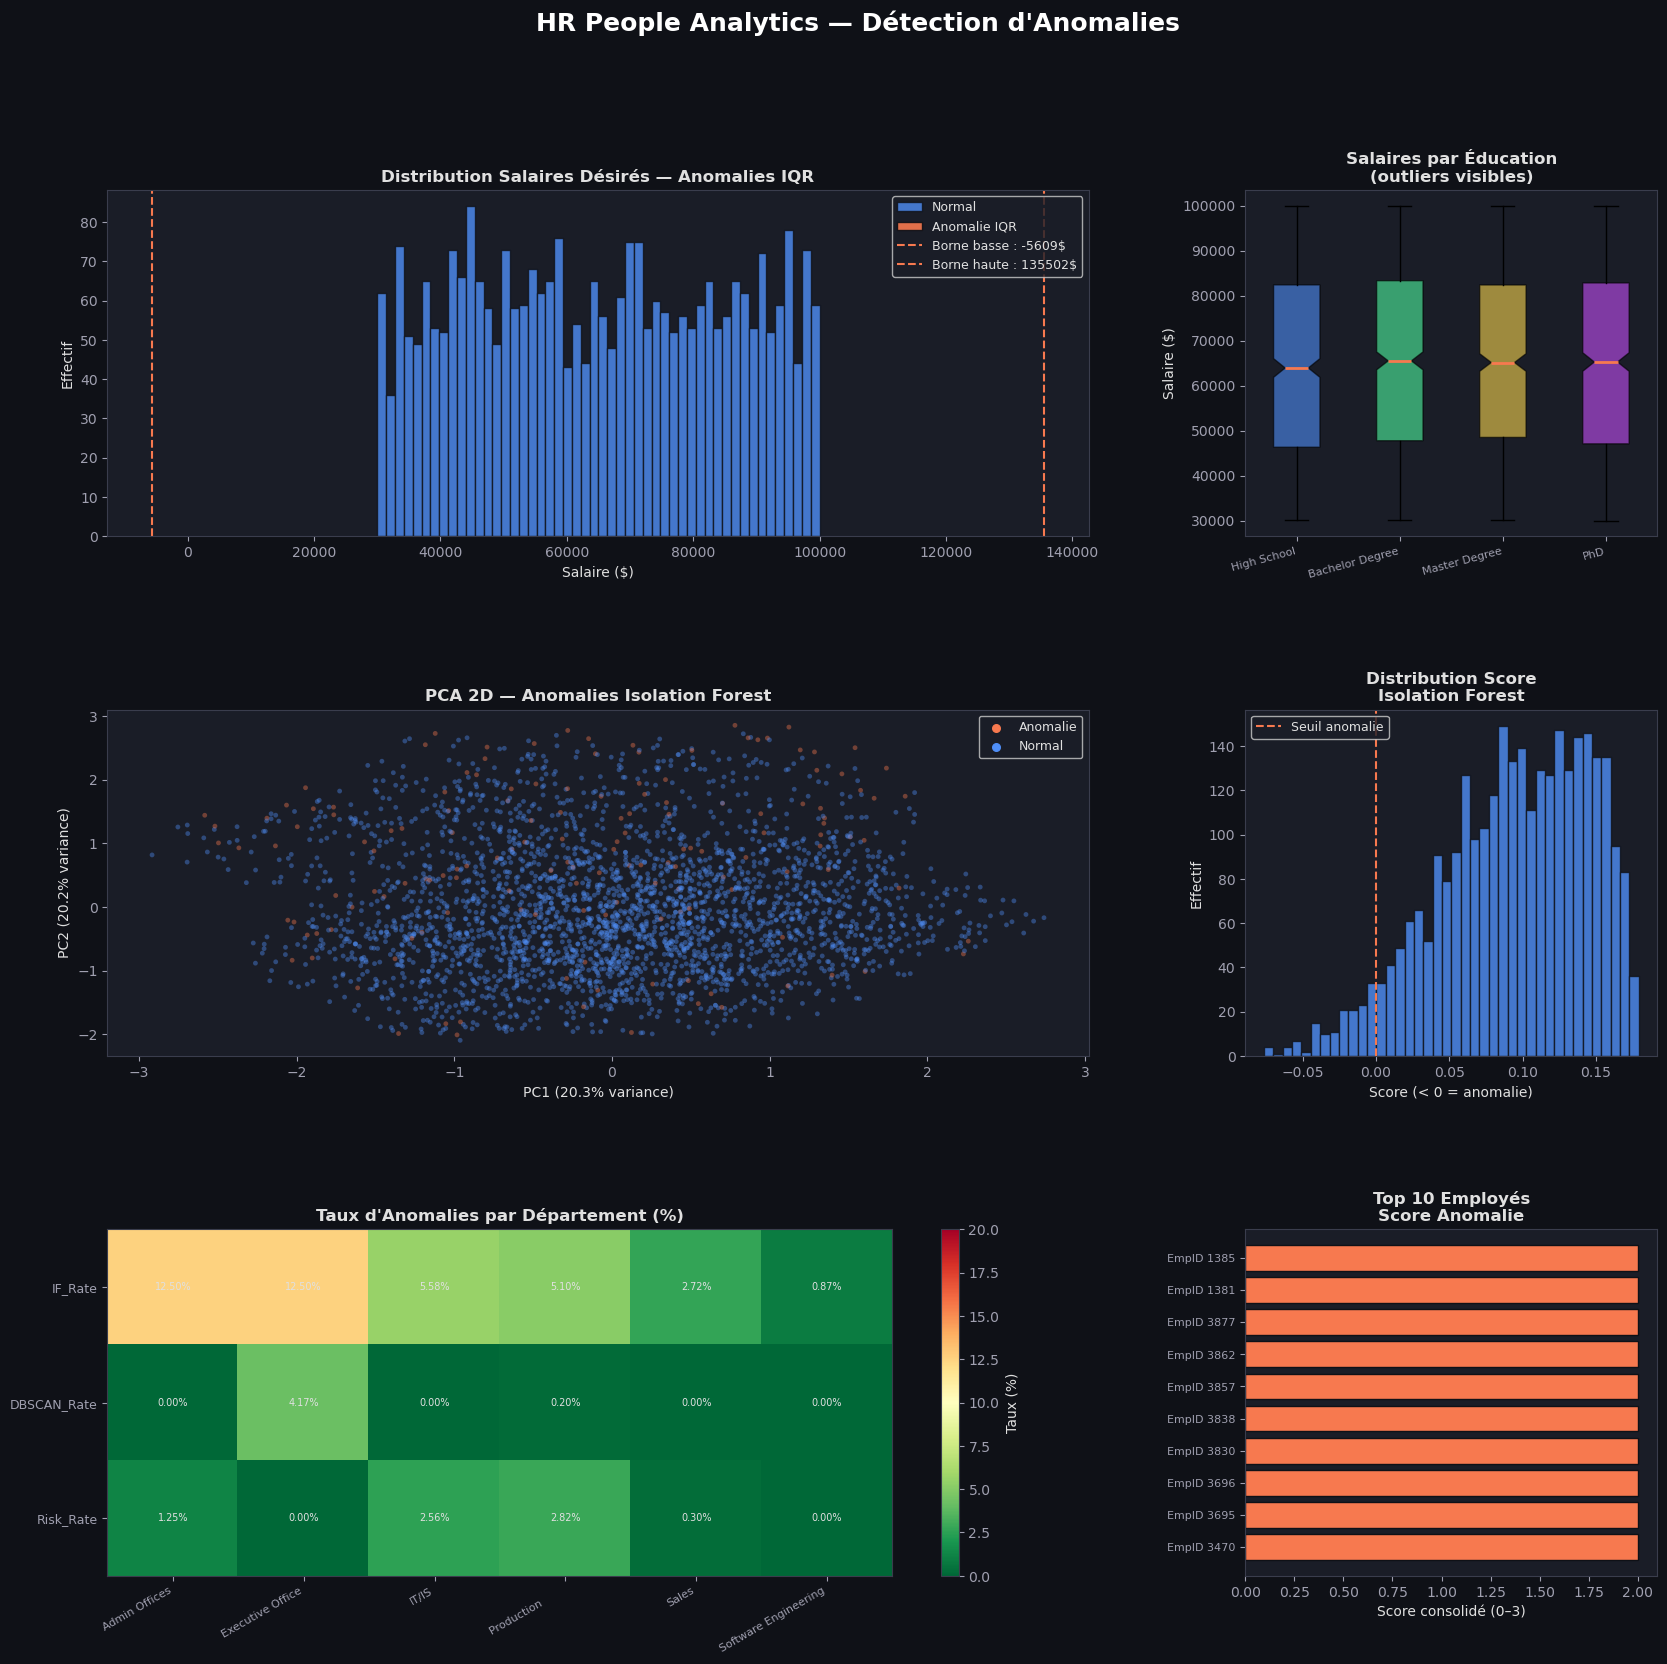

In [ ]:
print("\nGénération des visualisations...")

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)


# 7.1 Distribution salaires + bornes IQR
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(recruit["Desired Salary"].dropna(), bins=50,
         color=ACCENT, edgecolor="#0f1117", alpha=0.8, label="Normal")
ax1.hist(iqr_anomalies["Desired Salary"], bins=20,
         color=WARN, edgecolor="#0f1117", alpha=0.9, label="Anomalie IQR")
ax1.axvline(lower, color=WARN, linestyle="--", linewidth=1.5, label=f"Borne basse : {lower:.0f}$")
ax1.axvline(upper, color=WARN, linestyle="--", linewidth=1.5, label=f"Borne haute : {upper:.0f}$")
ax1.set_title("Distribution Salaires Désirés — Anomalies IQR", fontsize=12, fontweight="bold")
ax1.set_xlabel("Salaire ($)"); ax1.set_ylabel("Effectif")
ax1.legend(fontsize=9)


# 7.2 Boxplot salaire par éducation + outliers
ax2 = fig.add_subplot(gs[0, 2])
edu_order = ["High School", "Bachelor's Degree", "Master's Degree", "PhD"]
edu_order  = [e for e in edu_order if e in recruit["Education Level"].values]
bp_data    = [recruit[recruit["Education Level"] == e]["Desired Salary"].dropna()
              for e in edu_order]
bp = ax2.boxplot(bp_data, labels=[e.replace("'s", "") for e in edu_order],
                 patch_artist=True, notch=True,
                 medianprops=dict(color=WARN, linewidth=2),
                 flierprops=dict(marker="o", color=WARN, alpha=0.5, markersize=4))
colors_bp = [ACCENT, "#4ff7a0", "#f7d44f", "#c44ff7"]
for patch, c in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax2.set_title("Salaires par Éducation\n(outliers visibles)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Salaire ($)")
plt.setp(ax2.get_xticklabels(), rotation=15, ha="right", fontsize=8)


# 7.3 PCA 2D — Isolation Forest
ax3 = fig.add_subplot(gs[1, :2])
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_if)
colors = [WARN if a == 1 else ACCENT for a in master["IF_Anomaly"]]
ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=12, linewidths=0)
ax3.scatter([], [], c=WARN,  label="Anomalie", s=30)
ax3.scatter([], [], c=ACCENT, label="Normal",   s=30)
ax3.set_title("PCA 2D — Anomalies Isolation Forest", fontsize=12, fontweight="bold")
ax3.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax3.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax3.legend(fontsize=9)


# 7.4 Score anomalie IF continu
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(master["IF_Raw_Score"], bins=40, color=ACCENT,
         edgecolor="#0f1117", alpha=0.8)
ax4.axvline(0, color=WARN, linestyle="--", linewidth=1.5,
            label="Seuil anomalie")
ax4.set_title("Distribution Score\nIsolation Forest", fontsize=12, fontweight="bold")
ax4.set_xlabel("Score (< 0 = anomalie)"); ax4.set_ylabel("Effectif")
ax4.legend(fontsize=9)


# 7.5 Heatmap anomalies par département
ax5 = fig.add_subplot(gs[2, :2])
dept_cols = [c for c in master.columns if c.startswith("DepartmentType_")]
if dept_cols:
    dept_names = [c.replace("DepartmentType_", "") for c in dept_cols]
    anomaly_by_dept = []
    for col, name in zip(dept_cols, dept_names):
        subset = master[master[col] == 1]
        if len(subset) > 0:
            anomaly_by_dept.append({
                "Department": name,
                "IF_Rate":      subset["IF_Anomaly"].mean() * 100,
                "DBSCAN_Rate":  subset["DBSCAN_Anomaly"].mean() * 100,
                "Risk_Rate":    subset["Attrition_Risk_Flag"].mean() * 100
            })
    dept_df = pd.DataFrame(anomaly_by_dept).set_index("Department")
    im = ax5.imshow(dept_df.T.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=20)
    ax5.set_xticks(range(len(dept_df))); ax5.set_xticklabels(dept_df.index, rotation=30, ha="right", fontsize=8)
    ax5.set_yticks(range(3));           ax5.set_yticklabels(dept_df.columns, fontsize=9)
    for i in range(3):
        for j in range(len(dept_df)):
            ax5.text(j, i, f"{dept_df.T.values[i,j]:.2f}%", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax5, label="Taux (%)")
    ax5.set_title("Taux d'Anomalies par Département (%)", fontsize=12, fontweight="bold")


# 7.6 Top 10 employés à risque
ax6 = fig.add_subplot(gs[2, 2])
top_risk = master.nlargest(10, "Anomaly_Score")[
    ["EmpID", "Anomaly_Score", "IF_Raw_Score"]
].reset_index(drop=True)
y_pos = range(len(top_risk))
bars  = ax6.barh(y_pos, top_risk["Anomaly_Score"],
                 color=[WARN if s >= 2 else ACCENT for s in top_risk["Anomaly_Score"]],
                 edgecolor="#0f1117")
ax6.set_yticks(y_pos)
ax6.set_yticklabels([f"EmpID {int(e)}" for e in top_risk["EmpID"]], fontsize=8)
ax6.set_title("Top 10 Employés\nScore Anomalie", fontsize=12, fontweight="bold")
ax6.set_xlabel("Score consolidé (0–3)")


# ── Titre ─────────────────────────────────────────────────────
fig.suptitle("HR People Analytics — Détection d'Anomalies",
             fontsize=18, fontweight="bold", color="white", y=0.98)

# plt.savefig("03_anomaly_detection.png", dpi=150, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
# plt.close()
# print("Sauvegardé : 03_anomaly_detection.png")

## Rapport synthèse

In [14]:
print("\n" + "="*55)
print("SYNTHÈSE ANOMALIES")
print("="*55)
print(f"  Salaires aberrants (IQR)      : {len(iqr_anomalies):>5}")
print(f"  Salaires aberrants (Z-score)  : {len(z_anomalies):>5}")
print(f"  Anomalies profil (Iso Forest) : {master['IF_Anomaly'].sum():>5}")
print(f"  Anomalies clustering (DBSCAN) : {master['DBSCAN_Anomaly'].sum():>5}")
print(f"  Coûts formation aberrants     : {training['Cost_Anomaly'].sum():>5}")
print(f"  Employés haute anomalie (2+)  : {master['High_Risk_Anomaly'].sum():>5}")
print("="*55)

master.to_csv("master_hr_anomalies.csv", index=False)
print("\nmaster_hr_anomalies.csv exporté")


SYNTHÈSE ANOMALIES
  Salaires aberrants (IQR)      :     0
  Salaires aberrants (Z-score)  :     0
  Anomalies profil (Iso Forest) :   150
  Anomalies clustering (DBSCAN) :     5
  Coûts formation aberrants     :     0
  Employés haute anomalie (2+)  :    38

master_hr_anomalies.csv exporté
